GAUSS JACOB METHOD

Iteration 1: x = [ 0.6         2.27272727 -1.1         1.875     ], Error = 2.272727272727273
Iteration 2: x = [ 1.04727273  1.71590909 -0.80522727  0.88522727], Error = 0.9897727272727272
Iteration 3: x = [ 0.93263636  2.05330579 -1.04934091  1.13088068], Error = 0.3373966942148763
Iteration 4: x = [ 1.01519876  1.95369576 -0.96810863  0.97384272], Error = 0.15703796487603305
Iteration 5: x = [ 0.9889913   2.01141473 -1.0102859   1.02135051], Error = 0.057718961307287486
Iteration 6: x = [ 1.00319865  1.99224126 -0.99452174  0.99443374], Error = 0.026916770226802944
Iteration 7: x = [ 0.99812847  2.00230688 -1.00197223  1.00359431], Error = 0.010065620869902814
Iteration 8: x = [ 1.00062513  1.9986703  -0.99903558  0.99888839], Error = 0.004705919560371252
Iteration 9: x = [ 0.99967415  2.00044767 -1.00036916  1.00061919], Error = 0.001777370422652913
Iteration 10: x = [ 1.0001186   1.99976795 -0.99982814  0.99978598], Error = 0.0008332116799193434
Iteration 11: x = [ 0.99994242  2.00

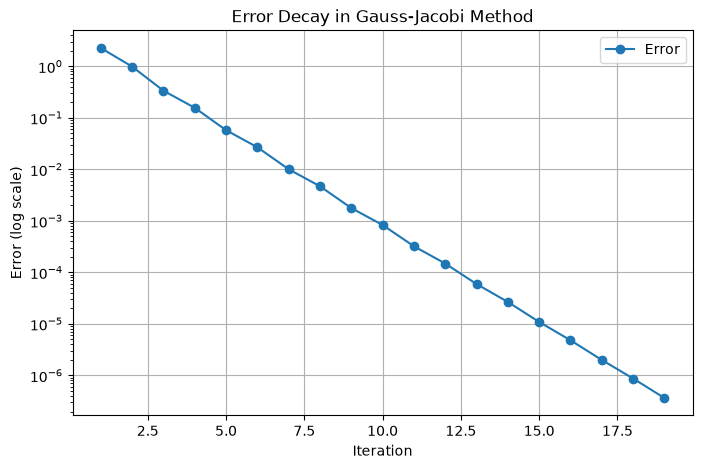

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gauss_jacobi(A, b, x0, tol=0.5e-6, max_iter=100):
    n = len(b)
    x = x0.copy()
    x_new = np.zeros_like(x)
    errors = []

    for k in range(max_iter):
        for i in range(n):
            sum_ = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - sum_) / A[i][i]

        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)

        print(f"Iteration {k+1}: x = {x_new}, Error = {error}")

        if error < tol:
            break

        x[:] = x_new  # Update x for next iteration

    return x_new, errors


def rate_of_convergence(errors):
    rates = []
    for i in range(1, len(errors) - 1):
        rate = np.log(errors[i+1] / errors[i]) / np.log(errors[i] / errors[i-1])
        rates.append(rate)
    return rates


# Example system
A = np.array([[10, -1, 2, 0],
              [-1, 11, -1, 3],
              [2, -1, 10, -1],
              [0, 3, -1, 8]], dtype=float)

b = np.array([6, 25, -11, 15], dtype=float)
x0 = np.zeros_like(b)

# Solve using Gauss-Jacobi
solution, errors = gauss_jacobi(A, b, x0)

# Compute rate of convergence
roc = rate_of_convergence(errors)
print("Rate of Convergence:", roc)

# Plot the error decay
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errors) + 1), errors, marker='o', linestyle='-', label='Error')
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Error (log scale)")
plt.title("Error Decay in Gauss-Jacobi Method")
plt.legend()
plt.grid(True)
plt.show()

GAUSS SEIDEL METHOD


little fast as compare to gauss

In [2]:
import numpy as np

def decompose_matrix(A):
    """ Decomposes A into L, D, and U """
    D = np.diag(np.diag(A))  # Diagonal matrix
    L = np.tril(A, -1)       # Lower triangular part
    U = np.triu(A, 1)        # Upper triangular part
    return L, D, U


def gauss_jacobi_matrix(L, D, U):
    """ Computes the iteration matrix for Gauss-Jacobi """
    D_inv = np.linalg.inv(D)  # Inverse of D
    T_J = -D_inv @ (L + U)
    return T_J


def gauss_seidel_matrix(L, D, U):
    """ Computes the iteration matrix for Gauss-Seidel """
    DL_inv = np.linalg.inv(D + L)  # Inverse of (D + L)
    T_G = -DL_inv @ U
    return T_G


def spectral_radius(T):
    """ Computes the spectral radius (max absolute eigenvalue) of matrix T """
    eigenvalues = np.linalg.eigvals(T)
    return max(abs(eigenvalues))


# Example usage
#A = np.array([[5, -1, 1],
#              [2, 8, -1],
#              [-4, 1, 10]], dtype=float) # Example matrix

A = np.array([[-4, 1, 10],
              [5, -1, 1],
              [2, 8, -1]], dtype=float)  # Example matrix


L, D, U = decompose_matrix(A)

print("L:\n", L)
print("D:\n", D)
print("U:\n", U)

T_J = gauss_jacobi_matrix(L, D, U)
T_G = gauss_seidel_matrix(L, D, U)

print("\nGauss-Jacobi Iteration Matrix:\n", T_J)
print("\nGauss-Seidel Iteration Matrix:\n", T_G)

# Compute eigenvalues and spectral radius
rho_J = spectral_radius(T_J)
rho_G = spectral_radius(T_G)

print(f"\nSpectral Radius of Gauss-Jacobi Matrix: {rho_J}")
print(f"Spectral Radius of Gauss-Seidel Matrix: {rho_G}")

# Rate of convergence (approximate)
rate_J = -np.log(rho_J) if rho_J < 1 else float('inf')
rate_G = -np.log(rho_G) if rho_G < 1 else float('inf')

print(f"\nRate of Convergence (approximate) for Gauss-Jacobi: {rate_J:.4f}")
print(f"Rate of Convergence (approximate) for Gauss-Seidel: {rate_G:.4f}")

L:
 [[0. 0. 0.]
 [5. 0. 0.]
 [2. 8. 0.]]
D:
 [[-4.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
U:
 [[ 0.  1. 10.]
 [ 0.  0.  1.]
 [ 0.  0.  0.]]

Gauss-Jacobi Iteration Matrix:
 [[0.   0.25 2.5 ]
 [5.   0.   1.  ]
 [2.   8.   0.  ]]

Gauss-Seidel Iteration Matrix:
 [[  0.     0.25   2.5 ]
 [  0.     1.25  13.5 ]
 [  0.    10.5  113.  ]]

Spectral Radius of Gauss-Jacobi Matrix: 5.657965150125582
Spectral Radius of Gauss-Seidel Matrix: 114.25437619999015

Rate of Convergence (approximate) for Gauss-Jacobi: inf
Rate of Convergence (approximate) for Gauss-Seidel: inf


FINDING CONVERGENCE MATRIX IN GAUSS JACOBI AND GAUSS SEIDEL

In [3]:
import numpy as np

def decompose_matrix(A):
    """ Decomposes A into L, D, and U """
    D = np.diag(np.diag(A))  # Diagonal matrix
    L = np.tril(A, -1)       # Lower triangular part
    U = np.triu(A, 1)        # Upper triangular part
    return L, D, U


def gauss_jacobi_matrix(L, D, U):
    """ Computes the iteration matrix for Gauss-Jacobi """
    D_inv = np.linalg.inv(D)  # Inverse of D
    T_J = -D_inv @ (L + U)
    return T_J


def gauss_seidel_matrix(L, D, U):
    """ Computes the iteration matrix for Gauss-Seidel """
    DL_inv = np.linalg.inv(D + L)  # Inverse of (D + L)
    T_G = -DL_inv @ U
    return T_G


def spectral_radius(T):
    """ Computes the spectral radius (max absolute eigenvalue) of matrix T """
    eigenvalues = np.linalg.eigvals(T)
    return max(abs(eigenvalues))


# Example usage
#A = np.array([[5, -1, 1],
#              [2, 8, -1],
#              [-4, 1, 10]], dtype=float) # Example matrix

A = np.array([[-4, 1, 10],
              [5, -1, 1],
              [2, 8, -1]], dtype=float)  # Example matrix


L, D, U = decompose_matrix(A)

print("L:\n", L)
print("D:\n", D)
print("U:\n", U)

T_J = gauss_jacobi_matrix(L, D, U)
T_G = gauss_seidel_matrix(L, D, U)

print("\nGauss-Jacobi Iteration Matrix:\n", T_J)
print("\nGauss-Seidel Iteration Matrix:\n", T_G)

# Compute eigenvalues and spectral radius
rho_J = spectral_radius(T_J)
rho_G = spectral_radius(T_G)

print(f"\nSpectral Radius of Gauss-Jacobi Matrix: {rho_J}")
print(f"Spectral Radius of Gauss-Seidel Matrix: {rho_G}")

# Rate of convergence (approximate)
rate_J = -np.log(rho_J) if rho_J < 1 else float('inf')
rate_G = -np.log(rho_G) if rho_G < 1 else float('inf')

print(f"\nRate of Convergence (approximate) for Gauss-Jacobi: {rate_J:.4f}")
print(f"Rate of Convergence (approximate) for Gauss-Seidel: {rate_G:.4f}")

L:
 [[0. 0. 0.]
 [5. 0. 0.]
 [2. 8. 0.]]
D:
 [[-4.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
U:
 [[ 0.  1. 10.]
 [ 0.  0.  1.]
 [ 0.  0.  0.]]

Gauss-Jacobi Iteration Matrix:
 [[0.   0.25 2.5 ]
 [5.   0.   1.  ]
 [2.   8.   0.  ]]

Gauss-Seidel Iteration Matrix:
 [[  0.     0.25   2.5 ]
 [  0.     1.25  13.5 ]
 [  0.    10.5  113.  ]]

Spectral Radius of Gauss-Jacobi Matrix: 5.657965150125582
Spectral Radius of Gauss-Seidel Matrix: 114.25437619999015

Rate of Convergence (approximate) for Gauss-Jacobi: inf
Rate of Convergence (approximate) for Gauss-Seidel: inf


OR 

In [4]:
import numpy as np

def decompose_matrix(A):
    """ Decomposes A into L, D, and U """
    D = np.diag(np.diag(A))  # Diagonal matrix
    L = np.tril(A, -1)       # Lower triangular part
    U = np.triu(A, 1)        # Upper triangular part
    return L, D, U


def gauss_jacobi_matrix(L, D, U):
    """ Computes the iteration matrix for Gauss-Jacobi """
    D_inv = np.linalg.inv(D)  # Inverse of D
    T_J = -D_inv @ (L + U)
    return T_J


def gauss_seidel_matrix(L, D, U):
    """ Computes the iteration matrix for Gauss-Seidel """
    DL_inv = np.linalg.inv(D + L)  # Inverse of (D + L)
    T_G = -DL_inv @ U
    return T_G


def spectral_radius(T):
    """ Computes the spectral radius (max absolute eigenvalue) of matrix T """
    eigenvalues = np.linalg.eigvals(T)
    return max(abs(eigenvalues))


#Example usage
A = np.array([[5, -1, 1],
             [2, 8, -1],
             [-4, 1, 10]], dtype=float) # Example matrix

# A = np.array([[-4, 1, 10],
#               [5, -1, 1],
#               [2, 8, -1]], dtype=float)  # Example matrix


L, D, U = decompose_matrix(A)

print("L:\n", L)
print("D:\n", D)
print("U:\n", U)

T_J = gauss_jacobi_matrix(L, D, U)
T_G = gauss_seidel_matrix(L, D, U)

print("\nGauss-Jacobi Iteration Matrix:\n", T_J)
print("\nGauss-Seidel Iteration Matrix:\n", T_G)

# Compute eigenvalues and spectral radius
rho_J = spectral_radius(T_J)
rho_G = spectral_radius(T_G)

print(f"\nSpectral Radius of Gauss-Jacobi Matrix: {rho_J}")
print(f"Spectral Radius of Gauss-Seidel Matrix: {rho_G}")

# Rate of convergence (approximate)
rate_J = -np.log(rho_J) if rho_J < 1 else float('inf')
rate_G = -np.log(rho_G) if rho_G < 1 else float('inf')

print(f"\nRate of Convergence (approximate) for Gauss-Jacobi: {rate_J:.4f}")
print(f"Rate of Convergence (approximate) for Gauss-Seidel: {rate_G:.4f}")

L:
 [[ 0.  0.  0.]
 [ 2.  0.  0.]
 [-4.  1.  0.]]
D:
 [[ 5.  0.  0.]
 [ 0.  8.  0.]
 [ 0.  0. 10.]]
U:
 [[ 0. -1.  1.]
 [ 0.  0. -1.]
 [ 0.  0.  0.]]

Gauss-Jacobi Iteration Matrix:
 [[ 0.     0.2   -0.2  ]
 [-0.25   0.     0.125]
 [ 0.4   -0.1    0.   ]]

Gauss-Seidel Iteration Matrix:
 [[ 0.      0.2    -0.2   ]
 [ 0.     -0.05    0.175 ]
 [ 0.      0.085  -0.0975]]

Spectral Radius of Gauss-Jacobi Matrix: 0.3790916711096453
Spectral Radius of Gauss-Seidel Matrix: 0.1980040240797054

Rate of Convergence (approximate) for Gauss-Jacobi: 0.9700
Rate of Convergence (approximate) for Gauss-Seidel: 1.6195


POWER AND INVERSE POWER METHOD

Power Method Eigenvalue: 4.999999999999999


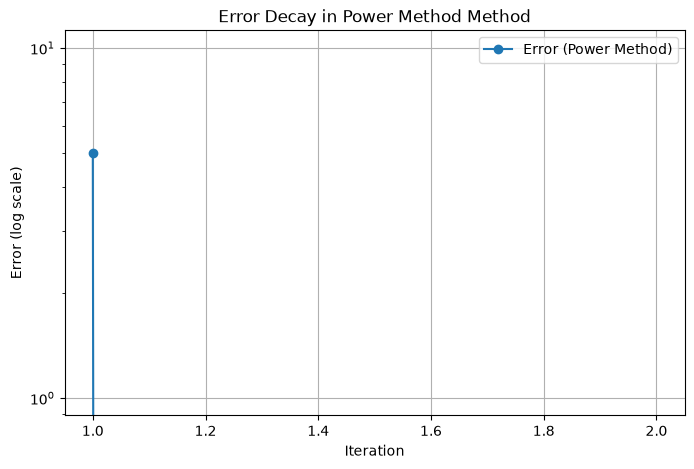

Inverse Power Method Eigenvalue: 0.19999999999999993


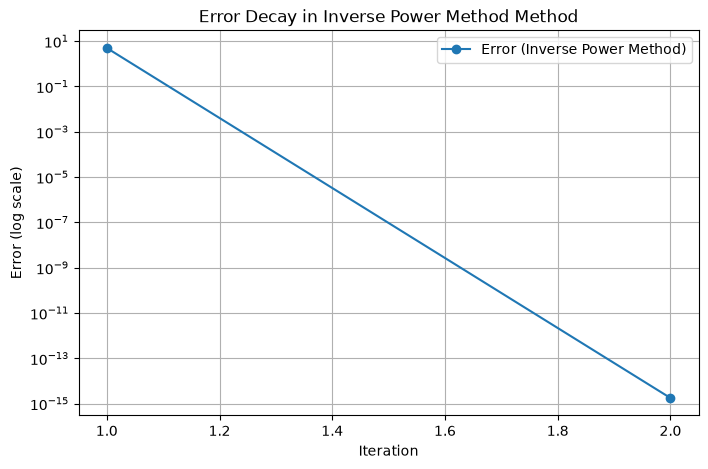

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def power_method(A, x0, tol=0.5e-6, max_iter=100):
    x = x0.copy()
    lambda_old = 0
    errors = []

    for k in range(max_iter):
        x = np.dot(A, x)
        x = x / np.linalg.norm(x)

        lambda_new = np.dot(x.T, np.dot(A, x))
        error = abs(lambda_new - lambda_old)
        errors.append(error)

        if error < tol:
            break

        lambda_old = lambda_new

    return lambda_new, x, errors


def inverse_power_method(A, x0, tol=0.5e-6, max_iter=100):
    x = x0.copy()
    lambda_old = 0
    errors = []

    A_inv = np.linalg.inv(A)

    for k in range(max_iter):
        x = np.dot(A_inv, x)
        x = x / np.linalg.norm(x)

        lambda_new = np.dot(x.T, np.dot(A, x))
        error = abs(lambda_new - lambda_old)
        errors.append(error)

        if error < tol:
            break

        lambda_old = lambda_new

    return 1/lambda_new, x, errors


def plot_errors(errors, method):
    plt.figure(figsize=(8, 5))
    plt.plot(
        range(1, len(errors) + 1),
        errors,
        marker='o',
        linestyle='-',
        label=f'Error ({method})'
    )
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Error (log scale)")
    plt.title(f"Error Decay in {method} Method")
    plt.legend()
    plt.grid(True)
    plt.show()


# Example usage
A = np.array([[4, 1], [2, 3]], dtype=float)
x0 = np.array([1, 1], dtype=float)

# Power Method
lambda_power, eigenvector_power, errors_power = power_method(A, x0)
print("Power Method Eigenvalue:", lambda_power)
plot_errors(errors_power, "Power Method")

# Inverse Power Method
lambda_inverse, eigenvector_inverse, errors_inverse = inverse_power_method(A, x0)
print("Inverse Power Method Eigenvalue:", lambda_inverse)
plot_errors(errors_inverse, "Inverse Power Method")

other example

Power Method Eigenvalue: 7.450749452947951


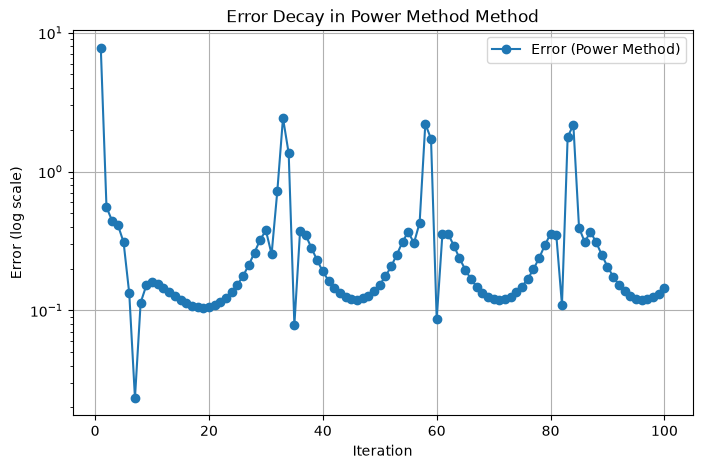

Inverse Power Method Eigenvalue: 0.14285690724443903


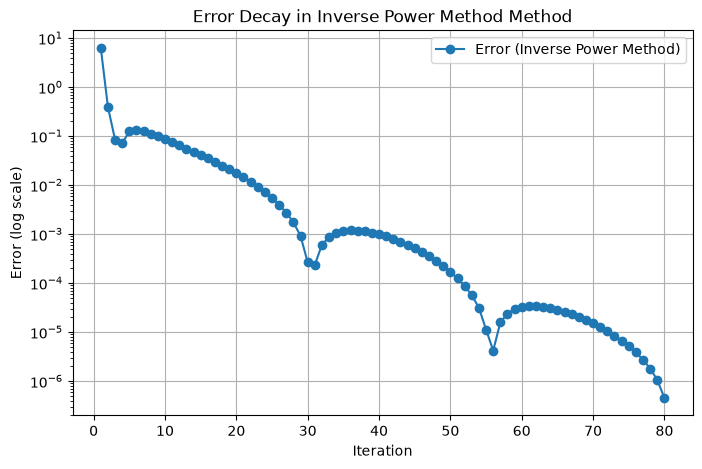

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def power_method(A, x0, tol=0.5e-6, max_iter=100):
    x = x0.copy()
    lambda_old = 0
    errors = []

    for k in range(max_iter):
        x = np.dot(A, x)
        x = x / np.linalg.norm(x)

        lambda_new = np.dot(x.T, np.dot(A, x))
        error = abs(lambda_new - lambda_old)
        errors.append(error)

        if error < tol:
            break

        lambda_old = lambda_new

    return lambda_new, x, errors


def inverse_power_method(A, x0, tol=0.5e-6, max_iter=100):
    x = x0.copy()
    lambda_old = 0
    errors = []

    A_inv = np.linalg.inv(A)

    for k in range(max_iter):
        x = np.dot(A_inv, x)
        x = x / np.linalg.norm(x)

        lambda_new = np.dot(x.T, np.dot(A, x))
        error = abs(lambda_new - lambda_old)
        errors.append(error)

        if error < tol:
            break

        lambda_old = lambda_new

    return 1/lambda_new, x, errors


def plot_errors(errors, method):
    plt.figure(figsize=(8, 5))
    plt.plot(
        range(1, len(errors) + 1),
        errors,
        marker='o',
        linestyle='-',
        label=f'Error ({method})'
    )
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Error (log scale)")
    plt.title(f"Error Decay in {method} Method")
    plt.legend()
    plt.grid(True)
    plt.show()


# Example usage
#A = np.array([[4, 1], [2, 3]], dtype=float)
#x0 = np.array([1, 1], dtype=float)

A = np.array([[5, -1, 1],
              [2, 8, -1],
              [-4, 1, 10]])

x0 = np.array([1, 1, 1], dtype=float)


# Power Method
lambda_power, eigenvector_power, errors_power = power_method(A, x0)
print("Power Method Eigenvalue:", lambda_power)
plot_errors(errors_power, "Power Method")


# Inverse Power Method
lambda_inverse, eigenvector_inverse, errors_inverse = inverse_power_method(A, x0)
print("Inverse Power Method Eigenvalue:", lambda_inverse)
plot_errors(errors_inverse, "Inverse Power Method")

In [1]:
5*4

20